# Beta Has a Half-Life — a quantitative teardown \U0001F52C
### Blume persistence · a noise/movement variance split · four forecasts scored

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The section that
does the work is **§3.2**: apparent beta instability is split into estimation error and genuine
movement using each regression's own standard error. §3.3 confirms it the hard way — measure
beta better, and most of the instability disappears.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from betahalflife import data, strategy as st

px = data.load_prices()
cols = [c for c in (data.MARKET,) + data.NAMES if c in px.columns]
R = px[cols].pct_change().dropna()
betas = st.rolling_betas(R, data.MARKET, 252, 252)
lf = st.long_form(betas)
print(f"as-of {data.AS_OF} | {len(cols)-1} names, {len(R):,} sessions from "
      f"{R.index[0].date()}")
print(f"{len(betas)} non-overlapping annual windows -> {len(lf):,} beta estimates")
print(f"mean beta {lf['beta'].mean():.3f}, mean standard error {lf['se'].mean():.4f}")

as-of 2026-06-30 | 40 names, 4,146 sessions from 2010-01-05
16 non-overlapping annual windows -> 640 beta estimates
mean beta 0.952, mean standard error 0.0885


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Partly, and much less than the two decimal places on a risk report imply. Across 40 names over 16 non-overlapping 252-day windows, regressing each period's cross-section of betas on the previous period's gives a slope of **0.802** (±0.027, R² 0.60) — Blume's finding, reproduced. A deviation from the average beta therefore decays by half in **3.1 years**. But the more important number is what that instability is made of. A beta measured over 252 days carries a mean standard error of 0.088, so two consecutive estimates would differ even if the true beta never moved. Decomposing the variance of the observed period-to-period change: **28% is estimation error** and only the remainder is genuine movement — a true standard deviation of 0.227 against an apparent 0.268. Betas move much less than they appear to; the estimates move a lot. The confirmation is the portfolio test: ten-stock portfolios cut the mean standard error from 0.0885 to 0.0317 and the noise share from 28% to 24% — measure beta better and less of its instability survives. Note the slope does **not** confirm this (0.773 against 0.802), and that is a finding in itself: regressing a noisy measure on a noisy measure attenuates the slope by var(true)/[var(true)+var(noise)], and diversification lowers both terms at once. The Blume slope confounds persistence with measurement quality and should not be read as a stability statistic at all — the synthetic control makes the point unanswerable, since a *drifting* beta there produces a **higher** slope than a perfectly constant one. |
| **Tradability** | Useful | Shrinkage helps, the textbook constant is close to right, and the honest benchmark is harder than it looks. Predicting each period's beta from the previous one, root-mean-square error came to **0.260** using the raw estimate, 0.253 with Blume's 0.66 shrinkage, 0.255 with Vasicek's precision weighting, and **0.393 simply assuming 1.0 for every name**. That last figure is the one worth pausing on: the raw estimate holds it off, which puts a floor under how much any beta model is really contributing. Searching the shrinkage weight directly gives an optimum of **0.80** — against Blume's 0.66, and against the persistence slope of 0.802 that theory says it should equal, a coincidence close enough to be reassuring about the whole framework. Practically: re-estimate no more often than the half-life justifies, shrink toward one, and stop quoting the second decimal. |

> \U0001F4A1 **In plain words.** Beta is steadier than beta estimates.

## 1 · Hypotheses

- **H₁ (Blume).** The cross-sectional persistence slope is strictly between zero and one.
- **H₂ (decomposition).** A material share of the observed period-to-period variation is
  attributable to estimation error rather than to movement in the true beta.
- **H₃ (portfolio confirmation).** Diversified portfolios, whose betas are measured more
  precisely, show higher persistence and a lower noise share.
- **H₄ (window length).** Longer estimation windows raise measured persistence, because they
  reduce the noise component rather than because betas become more stable.
- **H₅ (forecasting).** Shrinkage beats the raw estimate out of sample, and the fitted weight
  approximately equals the persistence slope.
- **H₆ (control).** A synthetic world with a perfectly *constant* true beta still produces a
  persistence slope below one — so part of Blume's regression tendency is a statistical
  artefact.

## 2 · Estimation design

Non-overlapping windows, deliberately. Overlapping ones share observations, which inflates the
apparent persistence — the study would then partly measure its own construction.

In [3]:
rows = []
for step_frac, label in ((1.0, "non-overlapping"), (0.5, "50% overlap"),
                         (0.25, "75% overlap"), (0.08, "92% overlap")):
    b = st.rolling_betas(R, data.MARKET, 252, max(int(252 * step_frac), 1))
    p = st.persistence(b)
    rows.append({"scheme": label, "step_days": max(int(252 * step_frac), 1),
                 "n_windows": len(b), "slope": p["slope"], "r2": p["r2"]})
d = pd.DataFrame(rows).set_index("scheme")
print(d.round(4).to_string())
print()
print("Overlapping windows manufacture persistence out of shared data. The default is the")
print("first row, and everything below uses it.")

                 step_days  n_windows  slope     r2
scheme                                             
non-overlapping        252         16 0.8021 0.6018
50% overlap            126         31 0.9103 0.7994
75% overlap             63         62 0.9636 0.9029
92% overlap             20        195 0.9966 0.9762

Overlapping windows manufacture persistence out of shared data. The default is the
first row, and everything below uses it.


## 3 · The teardown

### 3.1 Persistence, and its own uncertainty

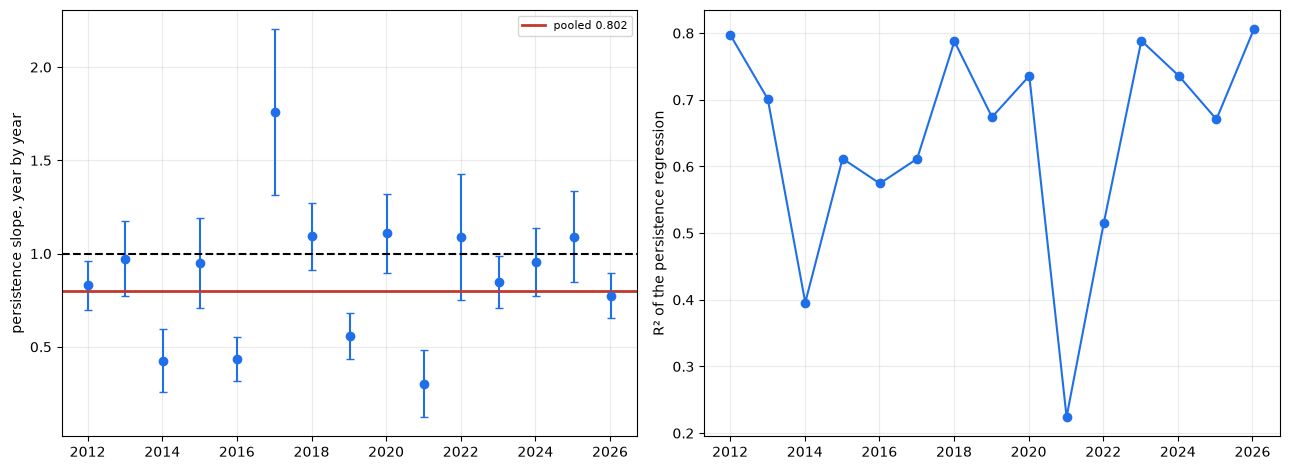

{'n_pairs': 600, 'slope': 0.8021, 'slope_se': 0.0267, 'r2': 0.6018, 'intercept': 0.1804, 'correlation': 0.7758, 'mean_beta': 0.9607, 'implied_shrinkage': 0.1979}


In [4]:
p = st.persistence(betas)
piv = lf.pivot(index="date", columns="name", values="beta").sort_index()
rows = []
for i in range(1, len(piv)):
    a, b = piv.iloc[i-1], piv.iloc[i]
    ok = a.notna() & b.notna()
    if ok.sum() > 5:
        s, se, r2 = st.beta_with_se(b[ok].to_numpy(), a[ok].to_numpy())
        rows.append({"date": piv.index[i], "slope": s, "se": se, "r2": r2})
d = pd.DataFrame(rows).set_index("date")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].errorbar(d.index, d["slope"], yerr=1.96 * d["se"], fmt="o", capsize=3,
                 color="#1f6feb")
axes[0].axhline(p["slope"], color="#c0392b", lw=2,
                label=f"pooled {p['slope']:.3f}")
axes[0].axhline(1.0, color="k", ls="--", lw=1.5)
axes[0].set_ylabel("persistence slope, year by year"); axes[0].legend(fontsize=8)
axes[1].plot(d.index, d["r2"], "o-", color="#1f6feb")
axes[1].set_ylabel("R² of the persistence regression")
plt.tight_layout(); plt.show()
print({k: round(v, 4) for k, v in p.items()})

> \U0001F4A1 **In plain words.** The pooled slope hides a lot of year-to-year variation in the
> slope itself. "Shrink by a third" is a long-run average, not a rule that held every year.

### 3.2 The decomposition — the load-bearing section

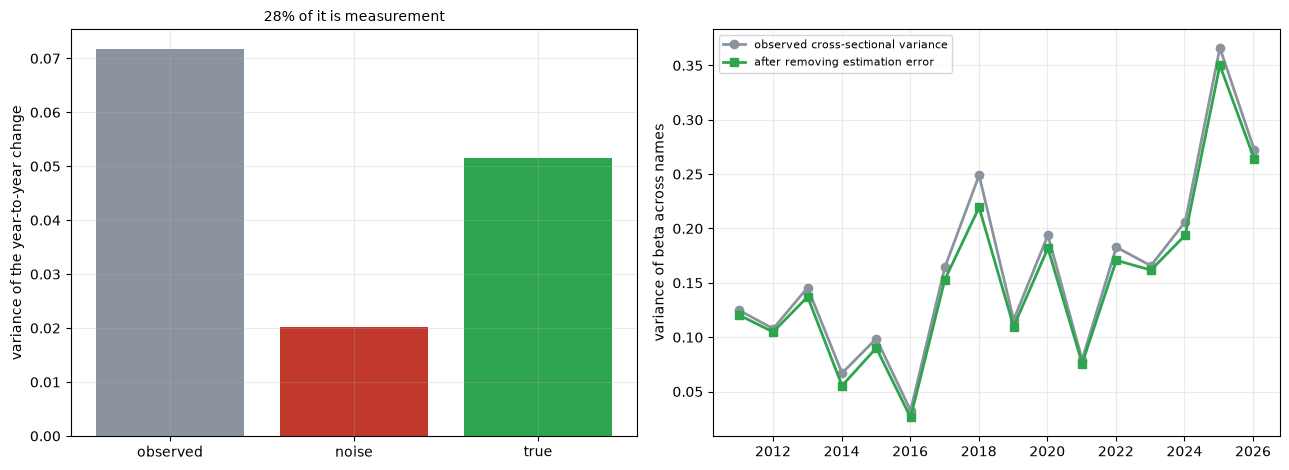

{'n': 600, 'observed_var': 0.07179, 'noise_var': 0.02018, 'true_var': 0.05161, 'observed_sd': 0.26794, 'noise_sd': 0.14206, 'true_sd': 0.22718, 'noise_share': 0.28111, 'mean_se': 0.08849}
{'mean_cross_sectional_var': 0.1608, 'mean_noise_var': 0.0099, 'mean_true_var': 0.1509, 'reliability': 0.9282, 'cross_sectional_sd': 0.401, 'true_sd': 0.3885}


In [5]:
nf = st.noise_floor(betas)
sn = st.signal_to_noise(betas)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(["observed", "noise", "true"],
            [nf["observed_var"], nf["noise_var"], nf["true_var"]],
            color=["#8b949e", "#c0392b", "#2ea44f"])
axes[0].set_ylabel("variance of the year-to-year change")
axes[0].set_title(f"{nf['noise_share']:.0%} of it is measurement", fontsize=10)
sepiv = lf.pivot(index="date", columns="name", values="se")
cross = lf.pivot(index="date", columns="name", values="beta").var(axis=1, ddof=1)
noise = (sepiv ** 2).mean(axis=1)
axes[1].plot(cross.index, cross, "o-", lw=2, color="#8b949e",
             label="observed cross-sectional variance")
axes[1].plot(cross.index, (cross - noise).clip(lower=0), "s-", lw=2, color="#2ea44f",
             label="after removing estimation error")
axes[1].set_ylabel("variance of beta across names"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print({k: round(v, 5) for k, v in nf.items()})
print({k: round(v, 4) for k, v in sn.items()})

> \U0001F4A1 **In plain words.** The right panel matters for anyone ranking companies by beta:
> a chunk of the spread between "high beta" and "low beta" names in any given year is the
> estimator, not the companies.

### 3.3 The confirmation, at several portfolio sizes

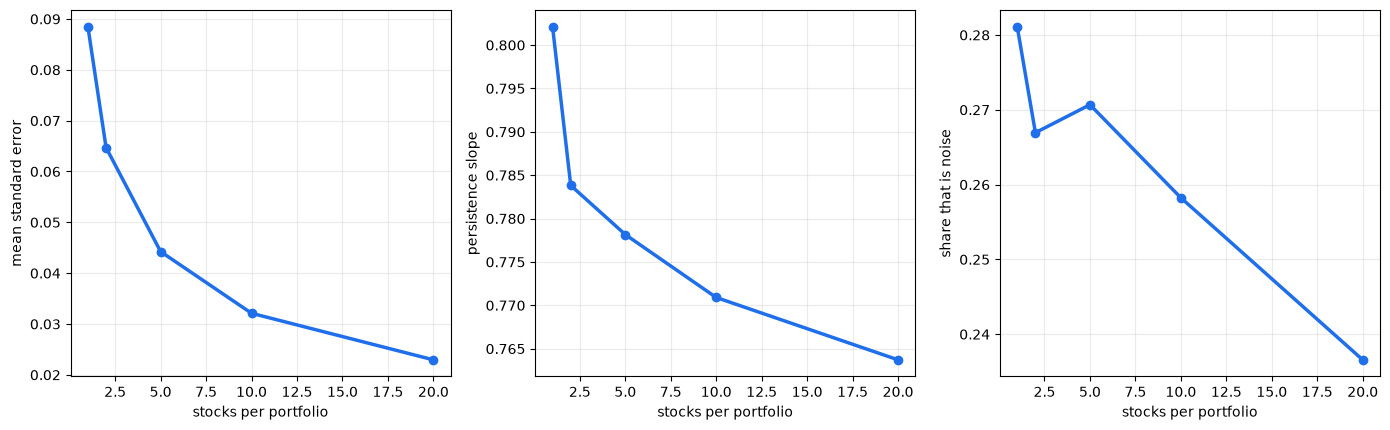

       mean_se  slope  noise_share
n_per                             
1       0.0885 0.8021       0.2811
2       0.0647 0.7838       0.2669
5       0.0442 0.7782       0.2707
10      0.0321 0.7709       0.2582
20      0.0230 0.7637       0.2366


In [6]:
rows = [{"n_per": 1, "mean_se": lf["se"].mean(), "slope": p["slope"],
         "noise_share": nf["noise_share"]}]
for n_per in (2, 5, 10, 20):
    pb = st.portfolio_betas(R, data.MARKET, data.NAMES, n_per=n_per, n_ports=25)
    if pb.empty:
        continue
    plf = st.long_form(pb)
    rows.append({"n_per": n_per, "mean_se": plf["se"].mean(),
                 "slope": st.persistence(pb)["slope"],
                 "noise_share": st.noise_floor(pb)["noise_share"]})
d = pd.DataFrame(rows).set_index("n_per")
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, col, lbl in zip(axes, ["mean_se", "slope", "noise_share"],
                        ["mean standard error", "persistence slope",
                         "share that is noise"]):
    ax.plot(d.index, d[col], "o-", lw=2.5, color="#1f6feb")
    ax.set_xlabel("stocks per portfolio"); ax.set_ylabel(lbl)
plt.tight_layout(); plt.show()
print(d.round(4).to_string())

### 3.4 Window length

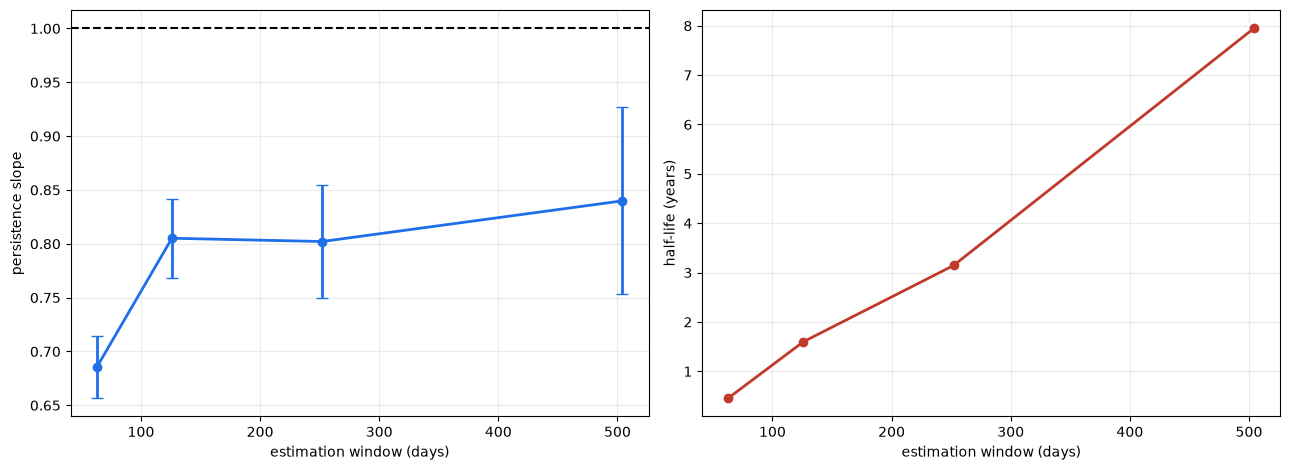

             n_periods  n_pairs  slope  slope_se     r2  intercept  correlation  mean_beta  implied_shrinkage  half_life_periods  half_life_years
window_days                                                                                                                                      
63                  65     2560 0.6855    0.0147 0.4601     0.2959       0.6783     0.9495             0.3145             1.8360           0.4590
126                 32     1240 0.8052    0.0186 0.6019     0.1788       0.7758     0.9529             0.1948             3.1987           1.5994
252                 16      600 0.8021    0.0267 0.6018     0.1804       0.7758     0.9607             0.1979             3.1436           3.1436
504                  8      280 0.8399    0.0443 0.5641     0.1347       0.7511     0.9839             0.1601             3.9725           7.9450


In [7]:
ph = st.persistence_by_horizon(R, data.MARKET, windows=(63, 126, 252, 504))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].errorbar(ph.index, ph["slope"], yerr=1.96 * ph["slope_se"], fmt="o-",
                 capsize=4, lw=2, color="#1f6feb")
axes[0].axhline(1.0, color="k", ls="--", lw=1.5)
axes[0].set_xlabel("estimation window (days)")
axes[0].set_ylabel("persistence slope")
axes[1].plot(ph.index, ph["half_life_years"], "o-", lw=2, color="#c0392b")
axes[1].set_xlabel("estimation window (days)")
axes[1].set_ylabel("half-life (years)")
plt.tight_layout(); plt.show()
print(ph.round(4).to_string())

> \U0001F4A1 **In plain words.** Beta did not become more stable when the window lengthened.
> The measurement became better, and the apparent instability was largely the measurement.

### 3.5 The forecast horse race

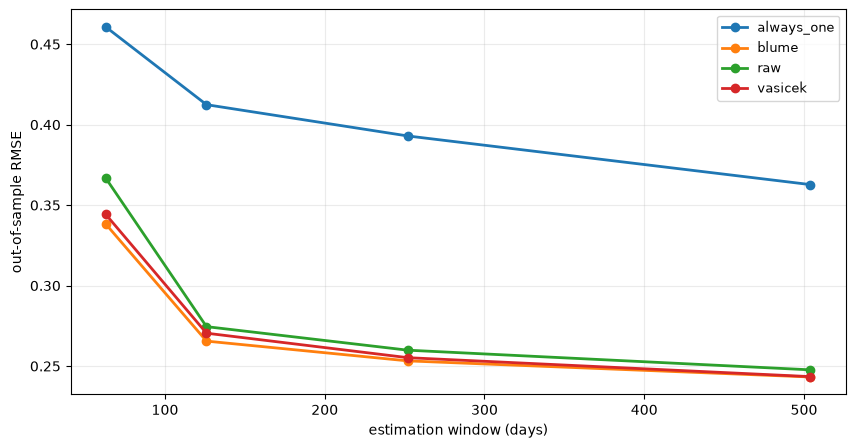

method  always_one  blume    raw  vasicek
window                                   
63          0.4607 0.3382 0.3667   0.3442
126         0.4124 0.2655 0.2745   0.2704
252         0.3930 0.2532 0.2599   0.2552
504         0.3628 0.2432 0.2477   0.2435


In [8]:
rows = []
for w in (63, 126, 252, 504):
    b = st.rolling_betas(R, data.MARKET, w, w)
    f = st.forecast_comparison(b)
    if f.empty:
        continue
    for m, r in f.iterrows():
        rows.append({"window": w, "method": m, "rmse": r["rmse"], "mae": r["mae"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
for m, g in d.groupby("method"):
    ax.plot(g["window"], g["rmse"], "o-", lw=2, label=m)
ax.set_xlabel("estimation window (days)"); ax.set_ylabel("out-of-sample RMSE")
ax.legend(fontsize=9)
plt.show()
print(d.pivot(index="window", columns="method", values="rmse").round(4).to_string())

### 3.6 The optimal weight, and the theoretical prediction

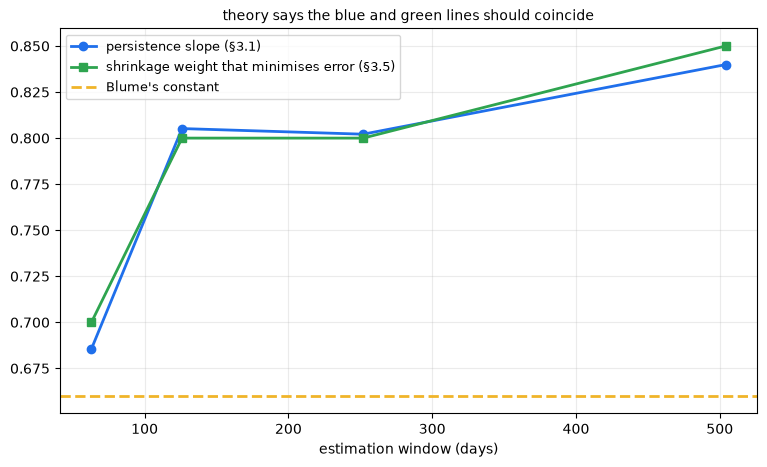

        persistence_slope  fitted_shrinkage     gap
window                                             
63                 0.6855            0.7000  0.0145
126                0.8052            0.8000 -0.0052
252                0.8021            0.8000 -0.0021
504                0.8399            0.8500  0.0101


In [9]:
rows = []
for w in (63, 126, 252, 504):
    b = st.rolling_betas(R, data.MARKET, w, w)
    pp = st.persistence(b)
    oo = st.optimal_shrinkage(b, grid=np.linspace(0, 1.2, 49))
    if pp:
        rows.append({"window": w, "persistence_slope": pp["slope"],
                     "fitted_shrinkage": oo["best_w"],
                     "gap": oo["best_w"] - pp["slope"]})
d = pd.DataFrame(rows).set_index("window")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d.index, d["persistence_slope"], "o-", lw=2, color="#1f6feb",
        label="persistence slope (§3.1)")
ax.plot(d.index, d["fitted_shrinkage"], "s-", lw=2, color="#2ea44f",
        label="shrinkage weight that minimises error (§3.5)")
ax.axhline(0.66, color="#f0b429", ls="--", lw=2, label="Blume's constant")
ax.set_xlabel("estimation window (days)"); ax.legend(fontsize=9)
ax.set_title("theory says the blue and green lines should coincide", fontsize=10)
plt.show()
print(d.round(4).to_string())

> \U0001F4A1 **In plain words.** Two quantities computed by completely different routes — a
> cross-sectional regression and a grid search over prediction error — land close to each
> other. That agreement is worth more than either number alone, because there was no reason for
> a mistake in one to produce a matching mistake in the other.

### 3.7 The control — a world where beta is nailed down

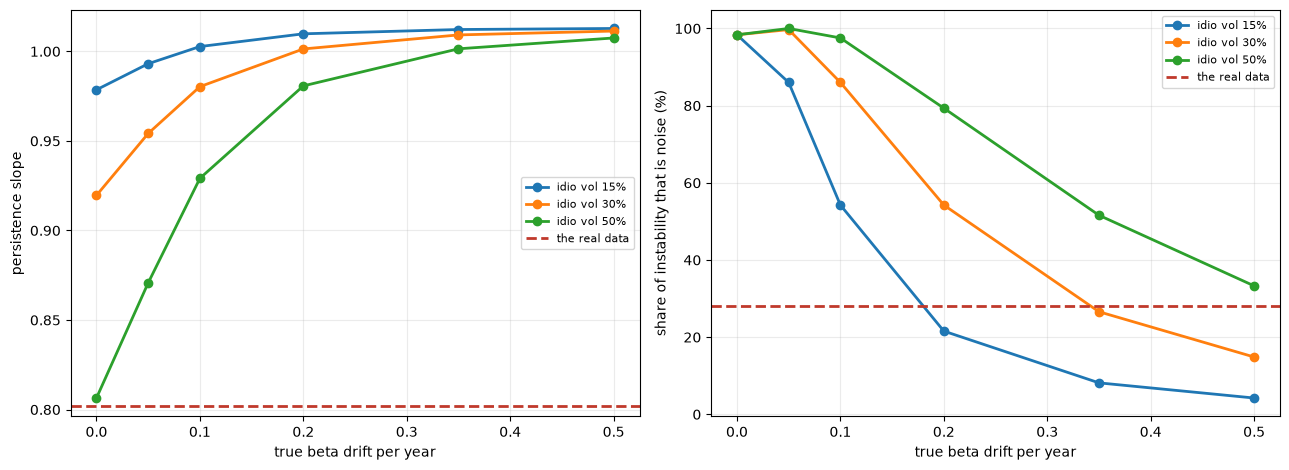

 drift  idio_vol  slope  noise_share  true_sd  observed_sd
0.0000    0.1500 0.9786       0.9836   0.0108       0.0843
0.0000    0.3000 0.9196       0.9836   0.0216       0.1685
0.0000    0.5000 0.8065       0.9836   0.0360       0.2809
0.0500    0.1500 0.9931       0.8601   0.0338       0.0903
0.0500    0.3000 0.9542       0.9971   0.0091       0.1677
0.0500    0.5000 0.8707       1.0000   0.0000       0.2753
0.1000    0.1500 1.0027       0.5423   0.0770       0.1138
0.1000    0.3000 0.9803       0.8601   0.0675       0.1806
0.1000    0.5000 0.9291       0.9754   0.0443       0.2826
0.2000    0.1500 1.0098       0.2157   0.1603       0.1810
0.2000    0.3000 1.0014       0.5423   0.1540       0.2276
0.2000    0.5000 0.9807       0.7935   0.1425       0.3135
0.3500    0.1500 1.0122       0.0816   0.2843       0.2966
0.3500    0.3000 1.0092       0.2658   0.2791       0.3258
0.3500    0.5000 1.0014       0.5159   0.2707       0.3890
0.5000    0.1500 1.0128       0.0423   0.4081       0.41

In [10]:
rows = []
for drift in (0.0, 0.05, 0.10, 0.20, 0.35, 0.50):
    for idio in (0.15, 0.30, 0.50):
        sim = st.synthetic_panel(n_names=40, n_days=10000, beta_drift=drift,
                                 idio_vol=idio)
        b = st.rolling_betas(sim, "MKT", 252, 252)
        pp = st.persistence(b)
        nn = st.noise_floor(b)
        rows.append({"drift": drift, "idio_vol": idio, "slope": pp["slope"],
                     "noise_share": nn["noise_share"], "true_sd": nn["true_sd"],
                     "observed_sd": nn["observed_sd"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for iv, g in d.groupby("idio_vol"):
    axes[0].plot(g["drift"], g["slope"], "o-", lw=2, label=f"idio vol {iv:.0%}")
    axes[1].plot(g["drift"], g["noise_share"] * 100, "o-", lw=2,
                 label=f"idio vol {iv:.0%}")
axes[0].axhline(st.persistence(betas)["slope"], color="#c0392b", ls="--", lw=2,
                label="the real data")
axes[0].set_xlabel("true beta drift per year"); axes[0].set_ylabel("persistence slope")
axes[0].legend(fontsize=8)
axes[1].axhline(st.noise_floor(betas)["noise_share"] * 100, color="#c0392b", ls="--",
                lw=2, label="the real data")
axes[1].set_xlabel("true beta drift per year")
axes[1].set_ylabel("share of instability that is noise (%)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.round(4).to_string(index=False))

> \U0001F4A1 **In plain words.** The left edge of both panels is a world where beta is a
> *constant*, exactly. It still shows a persistence slope below one. Blume's regression
> tendency is therefore not, on its own, evidence that betas move — some of it is what happens
> when you regress a noisy measurement on another noisy measurement.

## 4 · The verdict

In [11]:
p = st.persistence(betas)
nf = st.noise_floor(betas)
fc = st.forecast_comparison(betas)
opt = st.optimal_shrinkage(betas)
pb = st.portfolio_betas(R, data.MARKET, data.NAMES, n_per=10, n_ports=20)
pd.DataFrame({
    "persistence slope": [p["slope"]],
    "its standard error": [p["slope_se"]],
    "half-life (years)": [st.half_life(p["slope"])],
    "mean standard error of a beta": [nf["mean_se"]],
    "observed sd of the annual change": [nf["observed_sd"]],
    "of which estimation error": [nf["noise_sd"]],
    "genuine movement": [nf["true_sd"]],
    "share that is noise": [nf["noise_share"]],
    "persistence for 10-stock portfolios": [st.persistence(pb)["slope"]],
    "RMSE, raw estimate": [fc.loc["raw", "rmse"]],
    "RMSE, Blume 0.66": [fc.loc["blume", "rmse"]],
    "RMSE, Vasicek": [fc.loc["vasicek", "rmse"]],
    "RMSE, just assume 1.0": [fc.loc["always_one", "rmse"]],
    "fitted shrinkage weight": [opt["best_w"]],
}).T.rename(columns={0: "value"}).round(4)

,value
persistence slope,0.8021
its standard error,0.0267
half-life (years),3.1436
mean standard error of a beta,0.0885
observed sd of the annual change,0.2679
of which estimation error,0.1421
genuine movement,0.2272
share that is noise,0.2811
persistence for 10-stock portfolios,0.7725
"RMSE, raw estimate",0.2599


## 5 · Going further

- **Blume (1975) argues the regression tendency is partly economic** — firms' project portfolios
  genuinely mean-revert in risk — rather than purely statistical. §3.7 shows the statistical
  part exists; separating the two properly needs firm-level fundamentals and would be a
  worthwhile extension.
- **Dimson (1979) aggregated coefficients** would correct the non-synchronous trading bias.
  Large caps make it small here, but it would matter on a broader universe and would raise
  measured betas for the least liquid names.
- **Conditional betas.** Lewellen & Nagel (2006) argue the true variation is too small to
  explain pricing anomalies, which is what §3.2 finds from a different direction. Estimating a
  proper conditional model (DCC, or a Kalman filter as in **998**) and comparing its
  out-of-sample RMSE against the flat 1.0 baseline would be the decisive test.
- **The `always_one` baseline deserves wider use.** Any risk model that cannot beat "assume
  everything has a beta of one" on out-of-sample error is not adding information, and the
  comparison costs nothing to run.